In [1]:
import numpy as np
import pandas as pd

# Reproducible random numbers
rng = np.random.default_rng(42)

# Volume of titrant added (mL)
volume = np.linspace(0, 50, 51)

# True parameters
pH_low = 2.0
pH_high = 12.0
equivalence_point = 25.0
slope = 1.8

# Logistic titration model
def titration_model(v, pH_low, pH_high, v_eq, slope):
    return pH_low + (pH_high - pH_low) / (
        1 + np.exp(-(v - v_eq) / slope)
    )

# Generate noiseless curve
pH_true = titration_model(
    volume,
    pH_low,
    pH_high,
    equivalence_point,
    slope
)

# Add measurement noise
noise = rng.normal(0, 0.15, size=len(volume))
pH_observed = pH_true + noise

# Store in a DataFrame
df = pd.DataFrame({
    "volume_mL": volume,
    "pH": pH_observed
})

print(df.head())

# Optional: save for students
df.to_csv("fake_titration_data.csv", index=False)

   volume_mL        pH
0        0.0  2.045717
1        1.0  1.844019
2        2.0  2.112596
3        3.0  2.141134
4        4.0  1.707430


In [2]:
import numpy as np
from scipy.optimize import curve_fit

# Initial parameter guesses
p0 = [2, 12, 24, 2]

# Perform nonlinear least-squares fit
popt, pcov = curve_fit(
    titration_model,
    df["volume_mL"],
    df["pH"],
    p0=p0
)

# Extract fitted parameters
pH_low_fit, pH_high_fit, v_eq_fit, slope_fit = popt

print("Fitted parameters")
print(f"pH_low = {pH_low_fit:.3f}")
print(f"pH_high = {pH_high_fit:.3f}")
print(f"equivalence point = {v_eq_fit:.3f} mL")
print(f"slope = {slope_fit:.3f}")

Fitted parameters
pH_low = 1.998
pH_high = 12.027
equivalence point = 24.990 mL
slope = 1.777


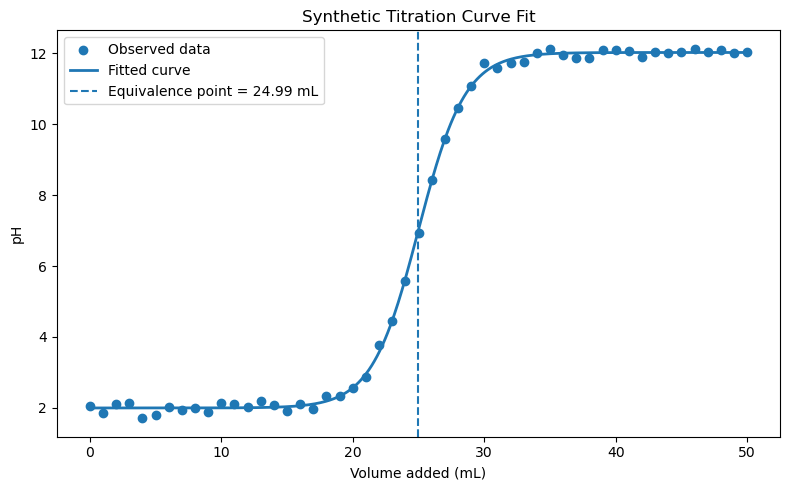

In [3]:
import matplotlib.pyplot as plt

# Smooth curve for plotting
v_smooth = np.linspace(
    df["volume_mL"].min(),
    df["volume_mL"].max(),
    500
)

pH_fit = titration_model(v_smooth, *popt)

plt.figure(figsize=(8, 5))

plt.scatter(
    df["volume_mL"],
    df["pH"],
    label="Observed data"
)

plt.plot(
    v_smooth,
    pH_fit,
    linewidth=2,
    label="Fitted curve"
)

plt.axvline(
    v_eq_fit,
    linestyle="--",
    label=f"Equivalence point = {v_eq_fit:.2f} mL"
)

plt.xlabel("Volume added (mL)")
plt.ylabel("pH")
plt.title("Synthetic Titration Curve Fit")
plt.legend()
plt.tight_layout()
plt.show()